In [1]:
import puremacro
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Parametros
delta_anual = {
    "inv_equip": 0.13,
    "inv_struct": 0.030,
    "inv_dwell": 0.011,
    "inv_ipp": 0.20,
    "dur_hogar": 0.21,
    "capital_publico": 0.04,
}
r_anual = 0.04

def a_trimestral(delta_anual):
    return 1 - (1 - delta_anual) ** 0.25

delta_q = {k: a_trimestral(v) for k, v in delta_anual.items()}
r_q = (1 + r_anual) ** 0.25 - 1

print("Deltas trimestrales:", delta_q)
print(f"r trimestral: {r_q:.5f}")

Deltas trimestrales: {'inv_equip': 0.034216429364797296, 'inv_struct': 0.007585882718504244, 'inv_dwell': 0.0027614170941110405, 'inv_ipp': 0.05425839099682417, 'dur_hogar': 0.057227789054238754, 'capital_publico': 0.01015359923204695}
r trimestral: 0.00985


In [3]:
# Datos
qna_gasto = pd.read_csv('/Users/isa/puremacro/curso_data/qna_gasto.csv', parse_dates=['date'])
qna_renta = pd.read_csv('/Users/isa/puremacro/curso_data/qna_renta.csv', parse_dates=['date'])
qna_labor = pd.read_csv('/Users/isa/puremacro/curso_data/qna_mercado_laboral.csv', parse_dates=['date'])
qna_meta = pd.read_csv('/Users/isa/puremacro/curso_data/qna_meta.csv')

panel = (qna_gasto
         .merge(qna_renta, on=['code', 'date'], how='left')
         .merge(qna_labor, on=['code', 'date'], how='left'))

panel = panel.set_index(['code', 'date']).sort_index()

print(panel.shape)
print(f"{panel.index.get_level_values('code').nunique()} países")

(5932, 61)
49 países


In [ ]:
# Intento: inversión de gobierno trimestral (sector S13), directo de la fuente SDMX
from puremacro.fetch.oecd_qna_panel import _download, _tidy, _AGENCY_FLOW

codes = panel.index.get_level_values('code').unique().tolist()
raw_s13 = _download(codes, start="1995", refresh=False)
lookup_gov = {("P51G", "S13"): "inv_gov"}
tidy_gov = _tidy(raw_s13, lookup_gov, ("TRANSACTION", "SECTOR"))

print(tidy_gov.shape)
if not tidy_gov.empty:
    print("Países con inv_gov:", tidy_gov['code'].nunique())
    print(tidy_gov[['code','PRICE_BASE']].drop_duplicates()['code'].value_counts().head())
else:
    print("Vacío: no hay inversión de gobierno (P51G, S13) en este dataflow.")

In [4]:
#Parte 1
panel['nx'] = panel['exports'] - panel['imports']
panel['absorcion'] = panel['cons_hh'] + panel['cons_gov'] + panel['inv']
panel['nx_y'] = panel['nx'] / panel['gdp']

nx_y_stats = panel.groupby('code')['nx_y'].agg(['mean', 'std']).sort_values('mean')
print(nx_y_stats)

          mean       std
code                    
LVA  -0.068984  0.061657
GRC  -0.066700  0.035334
ROU  -0.060711  0.034594
HRV  -0.049608  0.040546
COL  -0.044054  0.022215
PRT  -0.043341  0.044321
USA  -0.033010  0.011933
LTU  -0.028752  0.062961
IND  -0.027286  0.018633
BGR  -0.022128  0.088650
EST  -0.019177  0.057341
SVK  -0.016282  0.046318
TUR  -0.012364  0.027661
MEX  -0.012247  0.013409
GBR  -0.011475  0.012216
CRI  -0.009061  0.038410
POL  -0.004189  0.035030
ISR  -0.003174  0.029672
AUS  -0.001203  0.022079
BRA  -0.001093  0.019600
ESP   0.000964  0.031010
FRA   0.001602  0.016155
JPN   0.001654  0.014533
ISL   0.004206  0.065280
NZL   0.005166  0.020871
CAN   0.008739  0.026998
ZAF   0.009766  0.020725
ITA   0.014482  0.017928
HUN   0.014923  0.040628
BEL   0.017617  0.023163
ARG   0.020364  0.027827
AUT   0.023146  0.017945
CHL   0.024275  0.048511
SVN   0.025103  0.043338
IDN   0.025885  0.032279
CZE   0.026285  0.036604
KOR   0.027364  0.031626
FIN   0.029887  0.038838


In [5]:
panel['con_total_a'] = panel['cons_hh'] + panel['cons_gov']
panel['gdp_privado_b'] = panel['gdp'] - panel['cons_gov']
panel['absorcion_privada_b'] = panel['cons_hh'] + panel['inv']

print(panel[['gdp', 'cons_gov', 'gdp_privado_b']].groupby('code').mean())

               gdp      cons_gov  gdp_privado_b
code                                           
ARG   2.381631e+07  3.678212e+06   2.013809e+07
AUS   3.576504e+05  7.211998e+04   2.855304e+05
AUT   7.815971e+04  1.585313e+04   6.230658e+04
BEL   9.511352e+04  2.194051e+04   7.317301e+04
BGR   1.071133e+04  1.897477e+03   8.650576e+03
BRA   1.225230e+06  2.359031e+05   9.893272e+05
CAN   4.475688e+05  9.262767e+04   3.549411e+05
CHE   1.560582e+05  1.814805e+04   1.373770e+05
CHL   3.426400e+07  4.777219e+06   2.948678e+07
CHN   1.391030e+07           NaN            NaN
COL   2.278429e+08  3.378329e+07   1.940596e+08
CRI   5.579314e+06  8.647399e+05   4.714574e+06
CZE   1.077225e+06  2.142822e+05   8.629432e+05
DEU   7.200126e+05  1.439748e+05   5.724233e+05
DNK   4.722616e+05  1.158837e+05   3.563779e+05
ESP   2.545015e+05  4.798071e+04   2.065208e+05
EST   4.565308e+03  8.866696e+02   3.678638e+03
FIN   4.776038e+04  1.110754e+04   3.665284e+04
FRA   5.045759e+05  1.201474e+05   3.844

In [6]:
panel['gdp_privado_a'] = panel['gdp'] 
panel['diferencia_a_b'] = panel['gdp'] - panel['gdp_privado_b'] 
panel['diferencia_pct'] = panel['diferencia_a_b'] / panel['gdp']

reporte_robustez = panel.groupby('code')['diferencia_pct'].mean().dropna().sort_values(ascending=False)
print(reporte_robustez)

code
SWE    0.255994
ISL    0.248079
DNK    0.246637
NLD    0.237861
FRA    0.237078
ISR    0.232967
FIN    0.228460
BEL    0.228146
HRV    0.222825
SAU    0.221566
NOR    0.211916
HUN    0.210053
CAN    0.205150
SVK    0.204859
GRC    0.201785
AUT    0.201180
CZE    0.199464
DEU    0.198758
LVA    0.197090
AUS    0.194910
EST    0.193791
LTU    0.193687
BRA    0.192897
GBR    0.192583
SVN    0.191879
ITA    0.189860
NZL    0.186319
PRT    0.185656
ESP    0.185582
POL    0.184840
JPN    0.182788
RUS    0.180447
ZAF    0.179959
BGR    0.175519
LUX    0.163486
ARG    0.154743
ROU    0.154732
IRL    0.150506
CRI    0.149253
USA    0.146610
COL    0.145585
KOR    0.136531
TUR    0.131963
CHL    0.130905
CHE    0.116658
IND    0.109425
MEX    0.104874
IDN    0.083091
Name: diferencia_pct, dtype: float64


In [7]:
def construir_pim(inversion, delta_q, r_q, k0_window=8):
    inversion = inversion.dropna().sort_index()
    I0 = inversion.iloc[0]
    I_ref = inversion.iloc[k0_window-1] if len(inversion) > k0_window else inversion.iloc[-1]
    n_periodos = min(k0_window, len(inversion)) - 1
    g = (I_ref / I0) ** (1/n_periodos) - 1 if n_periodos > 0 else 0.0
    piso = -0.5 * delta_q
    if g < piso:
        g = piso
    K0 = I0 / (g + delta_q)
    K = pd.Series(index=inversion.index, dtype=float)
    K.iloc[0] = K0
    for i in range(1, len(inversion)):
        K.iloc[i] = (1 - delta_q) * K.iloc[i-1] + inversion.iloc[i]
    S = (r_q + delta_q) * K
    return K, S

In [8]:
Kd_list = []
paises_con_error = []

for pais in panel.index.get_level_values('code').unique():
    serie_pais = panel.loc[pais].sort_index()
    try:
        Kd, Sd = construir_pim(serie_pais['cons_dur'], delta_q['dur_hogar'], r_q)
        Kd_list.append(pd.DataFrame({'code': pais, 'date': Kd.index, 'Kd': Kd.values, 'Sd': Sd.values}))
    except Exception as e:
        paises_con_error.append((pais, str(e)))

resultado_hogar = pd.concat(Kd_list).set_index(['code', 'date'])
print(resultado_hogar.shape)
print("Paises c error:", paises_con_error)

(4765, 2)
Paises c error: [('ARG', 'single positional indexer is out-of-bounds'), ('AUS', 'single positional indexer is out-of-bounds'), ('BRA', 'single positional indexer is out-of-bounds'), ('CHE', 'single positional indexer is out-of-bounds'), ('CHN', 'single positional indexer is out-of-bounds'), ('COL', 'single positional indexer is out-of-bounds'), ('IDN', 'single positional indexer is out-of-bounds'), ('IND', 'single positional indexer is out-of-bounds'), ('RUS', 'single positional indexer is out-of-bounds'), ('SAU', 'single positional indexer is out-of-bounds')]


In [9]:
cobertura_dur = panel.groupby('code')['cons_dur'].apply(lambda s: s.notna().sum())
print(cobertura_dur.sort_values())

code
ARG      0
AUS      0
CHE      0
BRA      0
COL      0
CHN      0
IND      0
IDN      0
RUS      0
SAU      0
ZAF     65
TUR     69
CHL    122
BGR    125
CAN    125
CZE    125
LTU    125
KOR    125
GRC    125
EST    125
HRV    125
HUN    125
IRL    125
FIN    125
ISL    125
ITA    125
LVA    125
POL    125
DNK    125
DEU    125
AUT    125
BEL    125
SVK    125
PRT    125
NZL    125
ROU    125
SWE    125
NOR    125
MEX    125
LUX    125
JPN    126
ISR    126
GBR    126
FRA    126
CRI    126
ESP    126
SVN    126
NLD    126
USA    126
Name: cons_dur, dtype: int64


In [10]:
import requests
import io

url = "https://sdmx.oecd.org/public/rest/data/OECD.SDD.NAD,DSD_NASEC10@DF_TABLE14_GFCF,1.0/all"
params = {"format": "csvfile"}
resp = requests.get(url, params=params, timeout=60)
gfcf_sector = pd.read_csv(io.StringIO(resp.text))

gfcf_filtrado = gfcf_sector[
    (gfcf_sector['TRANSACTION'] == 'P51G') &
    (gfcf_sector['INSTR_ASSET'] == 'N11G') &
    (gfcf_sector['SECTOR'].isin(['S1', 'S13']))
].copy()
gfcf_corriente = gfcf_filtrado[gfcf_filtrado['PRICE_BASE'] == 'V'].copy()
gfcf_wide = gfcf_corriente.pivot_table(index=['REF_AREA','TIME_PERIOD'], columns='SECTOR', values='OBS_VALUE').reset_index()
gfcf_wide.columns.name = None
gfcf_wide = gfcf_wide.rename(columns={'S1': 'inv_total_anual', 'S13': 'inv_gob_anual'})
gfcf_wide['ratio_gob'] = gfcf_wide['inv_gob_anual'] / gfcf_wide['inv_total_anual']
ratio_por_pais = gfcf_wide.groupby('REF_AREA')['ratio_gob'].agg(['mean','std','count']).sort_values('mean')

paises_49 = panel.index.get_level_values('code').unique().tolist()
paises_sin_ratio = [p for p in paises_49 if p not in ratio_por_pais.index]
print(f"Cobertura del ratio: {len(ratio_por_pais)} de {len(paises_49)} países")
print("Sin ratio:", paises_sin_ratio)

Cobertura del ratio: 45 de 49 países
Sin ratio: ['ARG', 'BGR', 'IDN', 'IND', 'ISL', 'SAU']


In [11]:
#Proxy para que jale
ratio_dict = ratio_por_pais['mean'].to_dict()
panel = panel.reset_index()
panel['ratio_inv_gob'] = panel['code'].map(ratio_dict)
panel['inv_gob_proxy'] = panel['inv'] * panel['ratio_inv_gob']
panel = panel.set_index(['code', 'date'])

cobertura_ratio = panel.groupby('code')['ratio_inv_gob'].apply(lambda s: s.notna().sum() > 0)
print("Países sin ratio de gobierno:", cobertura_ratio[~cobertura_ratio].index.tolist())

Kg_list = []
paises_con_error_g = []

for pais in panel.index.get_level_values('code').unique():
    serie_pais = panel.loc[pais].sort_index()
    try:
        Kg, Sg = construir_pim(serie_pais['inv_gob_proxy'], delta_q['capital_publico'], r_q)
        Kg_list.append(pd.DataFrame({'code': pais, 'date': Kg.index, 'Kg': Kg.values, 'Sg': Sg.values}))
    except Exception as e:
        paises_con_error_g.append((pais, str(e)))

resultado_gobierno = pd.concat(Kg_list).set_index(['code', 'date'])
print(resultado_gobierno.shape)
print("Paises c error:", paises_con_error_g)

Países sin ratio de gobierno: ['ARG', 'BGR', 'IDN', 'IND', 'ISL', 'SAU']
(5163, 2)
Paises c error: [('ARG', 'single positional indexer is out-of-bounds'), ('BGR', 'single positional indexer is out-of-bounds'), ('CHN', 'single positional indexer is out-of-bounds'), ('IDN', 'single positional indexer is out-of-bounds'), ('IND', 'single positional indexer is out-of-bounds'), ('ISL', 'single positional indexer is out-of-bounds'), ('SAU', 'single positional indexer is out-of-bounds')]


In [12]:
#Parte 2 con gasto
if 'Kd' in panel.columns or 'Sd' in panel.columns:
    panel = panel.drop(columns=[c for c in ['Kd', 'Sd'] if c in panel.columns])
panel = panel.join(resultado_hogar[['Kd', 'Sd']], how='left')

panel['C_star'] = (panel['cons_hh'] - panel['cons_dur']) + panel['cons_gov'] + panel['Sd']
panel['I_star'] = panel['inv'] + panel['cons_dur']
panel['Y_star'] = panel['absorcion'] + panel['Sd']

panel['check_identidad'] = panel['Y_star'] - (panel['C_star'] + panel['I_star'])
print("Max error de cierre:", panel['check_identidad'].abs().max())
print("Num de paises con Y_star no-nulo:", panel.groupby('code')['Y_star'].apply(lambda s: s.notna().sum() > 0).sum())

Max error de cierre: 1.1920928955078125e-07
Num de paises con Y_star no-nulo: 39


In [13]:
duplicados = panel.index.duplicated().sum()
print("Filas con índice duplicado:", duplicados)

if duplicados > 0:
    ejemplos = panel.index[panel.index.duplicated(keep=False)]
    print(panel.loc[ejemplos].head(10))

Filas con índice duplicado: 0


In [14]:
fila_peor = panel['check_identidad'].abs().idxmax()
print("País y fecha con el peor error:", fila_peor)
print(panel.loc[fila_peor, ['cons_hh', 'cons_dur', 'cons_gov', 'inv', 'absorcion', 'Sd', 'C_star', 'I_star', 'Y_star', 'check_identidad']])

País y fecha con el peor error: ('KOR', Timestamp('2021-07-01 00:00:00'))
cons_hh            2.630910e+08
cons_dur           2.443720e+07
cons_gov           9.594210e+07
inv                1.750900e+08
absorcion          5.341231e+08
Sd                 2.590693e+07
C_star             3.605028e+08
I_star             1.995272e+08
Y_star             5.600300e+08
check_identidad    1.192093e-07
Name: (KOR, 2021-07-01 00:00:00), dtype: float64


In [15]:
panel['Cd_Ch'] = panel['cons_dur'] / panel['cons_hh']
panel['Sd_Ystar'] = panel['Sd'] / panel['Y_star']
panel['participacion_imputada'] = panel['Sd'] / panel['C_star']

reporte_parte2 = panel.groupby('code')[['Cd_Ch', 'Sd_Ystar', 'participacion_imputada']].mean().dropna()
print(reporte_parte2.sort_values('participacion_imputada', ascending=False))

         Cd_Ch  Sd_Ystar  participacion_imputada
code                                            
NZL   0.163782  0.087411                0.124277
NOR   0.150584  0.065623                0.095646
USA   0.117374  0.070398                0.095532
CAN   0.128090  0.066349                0.091830
AUT   0.113223  0.061233                0.086480
PRT   0.099511  0.058345                0.077912
GBR   0.096260  0.057497                0.074300
SVN   0.105636  0.052243                0.072795
DEU   0.092811  0.053716                0.072156
ITA   0.086553  0.052483                0.069370
DNK   0.102170  0.050783                0.069121
NLD   0.100889  0.050227                0.068327
KOR   0.092050  0.044034                0.068244
LUX   0.092488  0.046723                0.066542
ZAF   0.094385  0.052143                0.066118
FRA   0.085812  0.048839                0.065033
CHL   0.087127  0.044734                0.062869
JPN   0.073605  0.043338                0.062107
ISR   0.092514  0.04

In [16]:
cols_ingreso = ['comp_emp', 'gdp_income', 'emp_employees', 'emp_selfemp', 'surplus_mixed', 'taxes_prod_imp_net']
cobertura_ingreso = panel.groupby('code')[cols_ingreso].apply(lambda df: df.notna().mean())
print(cobertura_ingreso.round(2))

      comp_emp  gdp_income  emp_employees  emp_selfemp  surplus_mixed  \
code                                                                    
ARG       0.00        0.00           0.00         0.00           0.00   
AUS       1.00        1.00           1.00         1.00           1.00   
AUT       1.00        1.00           0.99         0.99           1.00   
BEL       1.00        1.00           1.00         1.00           1.00   
BGR       0.99        1.00           0.99         0.99           0.99   
BRA       0.00        0.00           0.00         0.00           0.00   
CAN       1.00        1.00           0.00         0.00           1.00   
CHE       0.99        1.00           0.99         0.99           0.99   
CHL       0.00        0.00           0.43         0.43           0.00   
CHN       0.00        0.00           0.00         0.00           0.00   
COL       0.48        0.48           0.00         0.00           0.48   
CRI       0.00        0.00           0.50         0

In [17]:
cols_clave = ['comp_emp', 'gdp_income', 'surplus_mixed', 'taxes_prod_imp_net']

grupo_proxy = []
grupo_directo = []
grupo_excluido = []

for pais in panel.index.get_level_values('code').unique():
    cov = panel.loc[pais][cols_clave + ['emp_employees', 'emp_selfemp']].notna().mean()
    if cov[cols_clave].min() >= 0.9 and cov['emp_employees'] < 0.1:
        grupo_proxy.append(pais)
    elif cov.min() >= 0.9:
        grupo_directo.append(pais)
    else:
        grupo_excluido.append(pais)

print("Directo:", grupo_directo)
print("Proxy (necesita autoempleo Banco Mundial):", grupo_proxy)
print("Excluido:", grupo_excluido)

Directo: ['AUS', 'AUT', 'BEL', 'BGR', 'CHE', 'CZE', 'DEU', 'DNK', 'ESP', 'EST', 'FIN', 'FRA', 'GBR', 'GRC', 'HRV', 'HUN', 'IRL', 'ITA', 'LTU', 'LUX', 'LVA', 'NLD', 'NOR', 'POL', 'PRT', 'ROU', 'SVK', 'SVN', 'SWE']
Proxy (necesita autoempleo Banco Mundial): ['CAN', 'TUR', 'USA']
Excluido: ['ARG', 'BRA', 'CHL', 'CHN', 'COL', 'CRI', 'IDN', 'IND', 'ISL', 'ISR', 'JPN', 'KOR', 'MEX', 'NZL', 'RUS', 'SAU', 'ZAF']


In [18]:
#Labor share para no proxy
import puremacro.labor_share as labor_share

panel_directo = panel.reset_index()
panel_directo = panel_directo[panel_directo['code'].isin(grupo_directo)]
df_gollin = panel_directo[['code','date','comp_emp','gdp_income','emp_employees','emp_selfemp']].copy()
df_gollin = df_gollin.rename(columns={
    'comp_emp': 'compensation_employees',
    'gdp_income': 'value_added',
    'emp_employees': 'employment_employees',
    'emp_selfemp': 'employment_self',
})
resultado_gollin_directo = labor_share.gollin_adjusted_ls(df_gollin).set_index(['code','date'])
print(resultado_gollin_directo.shape)

(3637, 5)


In [19]:
#Labor share para proxy
def bajar_self_employment(codigo_iso3):
    url = f"https://api.worldbank.org/v2/country/{codigo_iso3}/indicator/SL.EMP.SELF.ZS"
    params = {"format": "json", "per_page": 100}
    resp = requests.get(url, params=params, timeout=30)
    data = resp.json()
    return pd.DataFrame(data[1])[['date', 'value']].dropna()

selfemp_wb = {p: bajar_self_employment(p) for p in grupo_proxy}
for p, df_wb in selfemp_wb.items():
    print(p, df_wb.shape, df_wb['date'].min(), df_wb['date'].max())

CAN (35, 2) 1991 2025
TUR (35, 2) 1991 2025
USA (35, 2) 1991 2025


In [20]:
selfemp_all = pd.concat([
    df.assign(code=p, year=pd.to_datetime(df['date']).dt.year, s=df['value']/100)[['code','year','s']]
    for p, df in selfemp_wb.items()
])

panel_proxy = panel.reset_index()
panel_proxy = panel_proxy[panel_proxy['code'].isin(grupo_proxy)].copy()
panel_proxy['year'] = panel_proxy['date'].dt.year
panel_proxy = panel_proxy.merge(selfemp_all, on=['code', 'year'], how='left')

panel_proxy['renta_laboral_proxy'] = panel_proxy['comp_emp'] / (1 - panel_proxy['s'])
panel_proxy['ls_gollin'] = (panel_proxy['renta_laboral_proxy'] / panel_proxy['gdp_income']).clip(upper=1.0)

resultado_gollin_proxy = panel_proxy.set_index(['code', 'date'])[['ls_gollin']]

print(resultado_gollin_directo.columns.tolist())

['compensation_employees', 'value_added', 'employment_employees', 'employment_self', 'ls_gollin']


In [21]:
#Parte 3 

panel['Y_star_ingreso'] = panel['comp_emp'] + panel['surplus_mixed'] + panel['taxes_prod_imp_net'] + panel['Sd']

coe_por_empleado = panel['comp_emp'] / panel['emp_employees']
renta_laboral_imputada = panel['comp_emp'] + coe_por_empleado * panel['emp_selfemp']
panel['ls_transformado'] = renta_laboral_imputada / panel['Y_star_ingreso']

panel['ls_gollin'] = np.nan
panel.loc[panel.index.get_level_values('code').isin(grupo_directo), 'ls_gollin'] = \
    resultado_gollin_directo['ls_gollin'].reindex(panel[panel.index.get_level_values('code').isin(grupo_directo)].index)

panel['caida_ls'] = panel['ls_gollin'] - panel['ls_transformado']

reporte_parte3 = panel.groupby('code')[['ls_gollin', 'ls_transformado', 'caida_ls']].mean().dropna()
print(reporte_parte3.sort_values('caida_ls', ascending=False))

      ls_gollin  ls_transformado  caida_ls
code                                      
PRT    0.566858         0.532443  0.034416
AUT    0.557497         0.524379  0.033118
GBR    0.562362         0.529613  0.032749
SVN    0.622349         0.591104  0.031245
DEU    0.578464         0.548793  0.029671
FRA    0.569606         0.541949  0.027657
ITA    0.526005         0.498855  0.027150
NOR    0.462086         0.435003  0.027083
NLD    0.578466         0.551936  0.026530
DNK    0.548437         0.522339  0.026098
ESP    0.564281         0.539495  0.024786
HRV    0.588162         0.564929  0.023233
FIN    0.541042         0.518022  0.023019
BEL    0.603398         0.580688  0.022710
GRC    0.514156         0.492946  0.021210
SWE    0.499897         0.480436  0.019461
POL    0.514648         0.496253  0.018395
BGR    0.512616         0.494323  0.018293
LTU    0.499518         0.481409  0.018109
HUN    0.480981         0.463105  0.017876
LUX    0.513390         0.495817  0.017573
CZE    0.48

In [22]:
# Y*_gasto vs Y*_ingreso ?

panel['brecha_gasto_ingreso'] = panel['Y_star'] - panel['Y_star_ingreso']
panel['brecha_pct'] = panel['brecha_gasto_ingreso'] / panel['Y_star']

reporte_brecha = panel.groupby('code')[['brecha_pct']].agg(['mean', 'std']).dropna()
reporte_brecha.columns = ['brecha_pct_media', 'brecha_pct_std']
print(reporte_brecha.sort_values('brecha_pct_media', key=abs))

      brecha_pct_media  brecha_pct_std
code                                  
SVK           0.001038        0.047091
EST           0.003799        0.045730
BGR          -0.003809        0.077757
FRA          -0.005641        0.016218
TUR          -0.006917        0.027297
GBR           0.007353        0.009924
ESP          -0.008004        0.030601
POL          -0.011309        0.039131
CAN          -0.013381        0.027457
ITA          -0.017826        0.016738
LTU           0.019455        0.051776
ISR          -0.025441        0.018231
BEL          -0.026315        0.021671
USA           0.027585        0.012425
MEX           0.031557        0.019251
AUT          -0.031786        0.017139
PRT           0.034291        0.037388
CZE          -0.034705        0.036644
HUN          -0.035175        0.037503
FIN          -0.035880        0.039629
HRV           0.039040        0.031271
SVN          -0.039837        0.042953
LVA           0.043048        0.043200
KOR          -0.045830   

In [23]:
#Parte 4 KALDOR 
K_total_list = []
paises_con_error_k = []

activos = ['inv_equip', 'inv_struct', 'inv_dwell', 'inv_ipp']

for pais in panel.index.get_level_values('code').unique():
    serie_pais = panel.loc[pais].sort_index()
    K_activos_df = pd.DataFrame(index=serie_pais.index)
    for activo in activos:
        serie_activo = serie_pais[activo]
        if serie_activo.notna().sum() > 8:
            try:
                K_act, _ = construir_pim(serie_activo, delta_q[activo], r_q)
                K_activos_df[activo] = K_act.reindex(serie_pais.index)
            except Exception:
                pass
    if K_activos_df.shape[1] > 0:
        n_activos_validos = K_activos_df.shape[1]
        K_pais = K_activos_df.sum(axis=1, min_count=n_activos_validos)
        K_total_list.append(pd.DataFrame({'code': pais, 'date': K_pais.index, 'K_fisico': K_pais.values}))
    else:
        paises_con_error_k.append(pais)

resultado_K = pd.concat(K_total_list).set_index(['code', 'date'])
print(resultado_K.shape)
print("Paises sin ningun activo de capital fisico:", paises_con_error_k)
print("Filas con K_fisico == 0 (deberia ser 0):", (resultado_K['K_fisico'] == 0).sum())

(5227, 1)
Paises sin ningun activo de capital fisico: ['BEL', 'BRA', 'CHN', 'COL', 'IND', 'RUS', 'SAU']
Filas con K_fisico == 0 (deberia ser 0): 0


In [24]:
#Otro sanity check 
print(panel.loc['BEL'][['inv_equip', 'inv_struct', 'inv_dwell', 'inv_ipp', 'inv']].notna().mean())

inv_equip     0.0
inv_struct    0.0
inv_dwell     0.0
inv_ipp       0.0
inv           1.0
dtype: float64


In [25]:
if 'K_fisico' in panel.columns:
    panel = panel.drop(columns=['K_fisico'])
panel = panel.join(resultado_K, how='left')

panel['K_Y_estandar'] = panel['K_fisico'] / panel['gdp']
panel['Kstar_Ystar'] = (panel['K_fisico'] + panel['Kd']) / panel['Y_star']

reporte_parte4 = panel.groupby('code')[['K_Y_estandar', 'Kstar_Ystar']].mean().dropna()
print(reporte_parte4.sort_values('K_Y_estandar'))
print("\nPaises con Kaldor completo (K y K*):", len(reporte_parte4))

      K_Y_estandar  Kstar_Ystar
code                           
BGR       4.235606     4.579256
TUR       4.431427     4.813781
ROU       4.466951     4.515020
CRI       4.968285     5.250599
MEX       5.410199     5.670307
HUN       5.501268     6.088345
ISL       5.596010     6.002915
KOR       5.604314     6.238070
ZAF       5.682882     6.230481
LVA       5.886156     5.964448
POL       6.216529     6.613733
IRL       6.318735     8.476763
HRV       6.419598     6.528621
GBR       6.456275     6.894234
SVK       6.574847     6.903176
LTU       6.634226     6.816184
SVN       6.653731     7.395401
EST       6.773326     7.071483
ISR       6.820856     7.253393
CHL       7.073153     7.633474
DNK       7.136074     8.036436
USA       7.162532     7.512637
NLD       7.310078     8.414596
NOR       7.609227     9.069004
NZL       7.684959     8.386124
SWE       7.903197     8.555778
CZE       9.080769     9.635369
CAN       9.206898     9.684533
PRT      10.254668    10.192317
FIN     

In [26]:
for activo in ['inv_equip', 'inv_struct', 'inv_dwell', 'inv_ipp']:
    serie = panel.loc['GRC'][activo].dropna().sort_index()
    if len(serie) > 8:
        I0 = serie.iloc[0]
        I_ref = serie.iloc[7]
        g = (I_ref / I0) ** (1/7) - 1
        print(f"{activo}: I0={I0:.2f}, g_estimado={g:.4f}, delta_q={delta_q[activo]:.4f}")

inv_equip: I0=1022.90, g_estimado=0.0677, delta_q=0.0342
inv_struct: I0=1498.50, g_estimado=0.0275, delta_q=0.0076
inv_dwell: I0=1952.40, g_estimado=-0.0090, delta_q=0.0028
inv_ipp: I0=212.80, g_estimado=0.0280, delta_q=0.0543


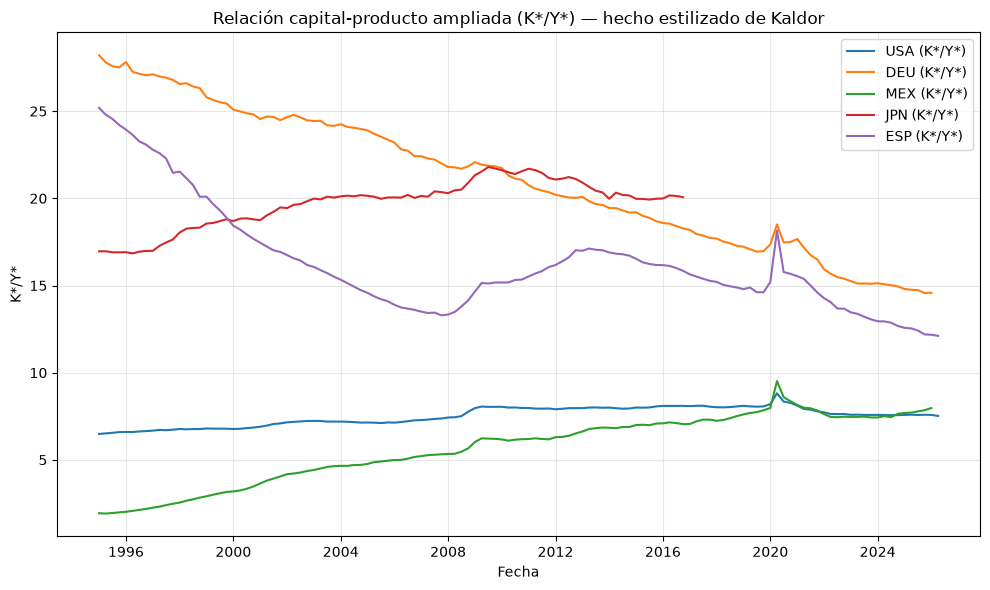

In [27]:
#Hecho mega estilizado 
paises_fig = ['USA', 'DEU', 'MEX', 'JPN', 'ESP']
fig, ax = plt.subplots(figsize=(10, 6))
for pais in paises_fig:
    serie = panel.loc[pais][['K_Y_estandar', 'Kstar_Ystar']].dropna()
    ax.plot(serie.index, serie['Kstar_Ystar'], label=f'{pais} (K*/Y*)')

ax.set_title('Relación capital-producto ampliada (K*/Y*) — hecho estilizado de Kaldor')
ax.set_xlabel('Fecha')
ax.set_ylabel('K*/Y*')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('/Users/isa/puremacro/parte4_kaldor.png', dpi=150)
plt.show()

In [28]:
from puremacro.data import hp_filter
from puremacro.cycles import hamilton_filter

panel_corto = panel[panel.index.get_level_values('date') <= '2019-10-01'].copy()
panel_corto['con_publicada'] = panel_corto['cons_hh'] + panel_corto['cons_gov']

variables_transformadas = {'Y*': 'Y_star', 'C*': 'C_star', 'I*': 'I_star'}
variables_publicadas = {'Y': 'gdp', 'C': 'con_publicada', 'I': 'inv'}

def tabla_momentos(panel_pais, variables, filtro='hp'):
    resultados = {}
    y_ciclo = None
    for nombre, col in variables.items():
        serie = panel_pais[col].dropna()
        if len(serie) < 20:
            continue
        log_serie = 100 * np.log(serie)
        if filtro == 'hp':
            ciclo, _ = hp_filter(log_serie, 1600)
        else:
            ciclo, _ = hamilton_filter(log_serie, h=8, p=4)
        ciclo = ciclo.dropna()
        resultados[nombre] = ciclo
        if nombre in ['Y*', 'Y']:
            y_ciclo = ciclo
    if y_ciclo is None:
        return pd.DataFrame()
    tabla = {}
    for nombre, ciclo in resultados.items():
        comun = ciclo.index.intersection(y_ciclo.index)
        if len(comun) < 10:
            continue
        sigma = ciclo.loc[comun].std()
        sigma_rel = sigma / y_ciclo.loc[comun].std()
        corr = ciclo.loc[comun].corr(y_ciclo.loc[comun])
        tabla[nombre] = {'sigma': sigma, 'sigma_rel': sigma_rel, 'corr_y': corr}
    return pd.DataFrame(tabla).T

resultados_completos = []
paises_con_error_ciclos = []

for pais in panel_corto.index.get_level_values('code').unique():
    serie_pais = panel_corto.loc[pais].sort_index()
    try:
        for filtro in ['hp', 'hamilton']:
            for tipo, variables in [('transformada', variables_transformadas), ('publicada', variables_publicadas)]:
                tabla = tabla_momentos(serie_pais, variables, filtro)
                if tabla.empty:
                    continue
                tabla['code'] = pais
                tabla['filtro'] = filtro
                tabla['tipo'] = tipo
                tabla['variable'] = tabla.index
                resultados_completos.append(tabla.reset_index(drop=True))
    except Exception as e:
        paises_con_error_ciclos.append((pais, str(e)))

tabla_final = pd.concat(resultados_completos, ignore_index=True)
print(tabla_final['code'].nunique(), "paises con al menos un momento")
print("Errores:", paises_con_error_ciclos)

49 paises con al menos un momento
Errores: []


In [29]:
#Summary yeiii 
resumen = tabla_final.groupby(['variable', 'filtro', 'tipo'])[['sigma_rel', 'corr_y']].mean()
print(resumen)

cobertura_ciclos = tabla_final.groupby(['tipo'])['code'].nunique()
print("\nPaíses por tipo:")
print(cobertura_ciclos)

                                sigma_rel    corr_y
variable filtro   tipo                             
C        hamilton publicada      0.750503  0.737880
         hp       publicada      0.740850  0.675666
C*       hamilton transformada   0.693852  0.808809
         hp       transformada   0.659052  0.772559
I        hamilton publicada      2.439537  0.702988
         hp       publicada      2.687233  0.667488
I*       hamilton transformada   2.290714  0.892840
         hp       transformada   2.469112  0.909176
Y        hamilton publicada      1.000000  1.000000
         hp       publicada      1.000000  1.000000
Y*       hamilton transformada   1.000000  1.000000
         hp       transformada   1.000000  1.000000

Países por tipo:
tipo
publicada       49
transformada    39
Name: code, dtype: int64


In [30]:
#Tabla cobertura 

def cobertura_nivel(cols_requeridas, umbral=0.9):
    """Cuenta países donde TODAS las columnas requeridas están disponibles
    en al menos `umbral` de los trimestres en que el país reporta PIB."""
    n_paises = 0
    for pais in panel.index.get_level_values('code').unique():
        df_pais = panel.loc[pais]
        n_base = df_pais['gdp'].notna().sum()
        if n_base == 0:
            continue
        disponible = df_pais[cols_requeridas].notna().all(axis=1).sum()
        if (disponible / n_base) >= umbral:
            n_paises += 1
    return n_paises

niveles = {}
niveles['1. Gasto completo (cerrar economía)'] = cobertura_nivel(['nx_y'])
niveles['2. + Privatizar'] = cobertura_nivel(['nx_y', 'gdp_privado_b'])
niveles['3. + Durabilidad (Kd/Sd)'] = cobertura_nivel(['nx_y', 'gdp_privado_b', 'Kd', 'Sd'])
niveles['4. + Capital físico total (K_fisico)'] = cobertura_nivel(['nx_y', 'gdp_privado_b', 'Kd', 'Sd', 'K_fisico'])
niveles['5. + Y* completo (gasto)'] = cobertura_nivel(['nx_y', 'gdp_privado_b', 'Kd', 'Sd', 'K_fisico', 'Y_star'])
niveles['6. + Lado del ingreso (Gollin)'] = cobertura_nivel(['nx_y', 'gdp_privado_b', 'Kd', 'Sd', 'K_fisico', 'Y_star', 'ls_gollin'])
niveles['7. + Comparación ingreso completa'] = cobertura_nivel(['nx_y', 'gdp_privado_b', 'Kd', 'Sd', 'K_fisico', 'Y_star', 'ls_gollin', 'ls_transformado'])

tabla_cobertura = pd.DataFrame.from_dict(niveles, orient='index', columns=['n_paises'])
tabla_cobertura['n_total'] = 49
tabla_cobertura['pct'] = (tabla_cobertura['n_paises'] / 49 * 100).round(1)
print(tabla_cobertura)

                                      n_paises  n_total   pct
1. Gasto completo (cerrar economía)         48       49  98.0
2. + Privatizar                             48       49  98.0
3. + Durabilidad (Kd/Sd)                    37       49  75.5
4. + Capital físico total (K_fisico)        35       49  71.4
5. + Y* completo (gasto)                    35       49  71.4
6. + Lado del ingreso (Gollin)              26       49  53.1
7. + Comparación ingreso completa           26       49  53.1


In [31]:
from puremacro.sa import residual_seasonality_F
help(residual_seasonality_F)

Help on function residual_seasonality_F in module puremacro.sa.stl:

residual_seasonality_F(series: 'pd.Series', *, freq: "Literal['Q', 'M']" = 'Q') -> 'tuple[float, float, int, int]'
    Test for residual seasonality in an SA series via one-way ANOVA on quarter.

    Returns (F, p_value, dof_num, dof_den). Computed on the second
    difference (so trend doesn't dominate F).



In [32]:
from puremacro.sa import deseasonalize_x13
help(deseasonalize_x13)

Help on function deseasonalize_x13 in module puremacro.sa.x13:

deseasonalize_x13(df: 'pd.DataFrame', value_col: 'str', *, by: 'str', date_col: 'str' = 'date', freq: "Literal['Q', 'M']" = 'Q', min_obs: 'int' = 24, engines: 'dict | None' = None) -> 'pd.Series'
    Return a seasonally-adjusted Series aligned to ``df.index``.

    Per unit, adjustment prefers the external X-13ARIMA-SEATS binary,
    falls back to the native pure-Python X-11/ARIMA engine
    (:mod:`puremacro.sa.x11`) when the binary is unavailable or declines,
    and to STL only when neither applies. This makes the browser default
    a genuine X-11-class adjuster rather than STL. Same group contract as
    :func:`puremacro.sa.stl.deseasonalize`; units below ``min_obs`` are
    returned as NaN. Pass ``engines`` as a dict to receive, per unit, the
    tag of the engine that actually ran (``'binary'`` / ``'native'`` /
    ``'stl'``) --- so callers can assert ``'stl'`` never sneaks in.



In [33]:
from puremacro.sa import residual_seasonality_F

variables_a_probar = ['gdp', 'Y_star', 'C_star', 'I_star', 'K_fisico']

resultados_sa = []
for pais in panel.index.get_level_values('code').unique():
    serie_pais = panel.loc[pais].sort_index()
    for var in variables_a_probar:
        serie = serie_pais[var].dropna()
        if len(serie) < 20:
            continue
        try:
            F, p, dof_num, dof_den = residual_seasonality_F(serie, freq='Q')
            resultados_sa.append({'code': pais, 'variable': var, 'F': F, 'p_value': p, 'n_obs': len(serie)})
        except Exception as e:
            resultados_sa.append({'code': pais, 'variable': var, 'F': None, 'p_value': None, 'error': str(e)})

tabla_sa = pd.DataFrame(resultados_sa)
fallan = tabla_sa[tabla_sa['p_value'] < 0.05]
print(f"Total pruebas: {len(tabla_sa)}")
print(f"Series que fallan el contraste (p<0.05): {len(fallan)}")
print(fallan[['code', 'variable', 'F', 'p_value']].sort_values('p_value'))

Total pruebas: 208
Series que fallan el contraste (p<0.05): 7
    code  variable         F   p_value
104  ISL    I_star  7.101331  0.000198
50   DNK    C_star  5.022123  0.002590
101  ISL       gdp  4.571341  0.004565
105  ISL  K_fisico  4.465413  0.005217
49   DNK    Y_star  3.671294  0.014245
96   IRL       gdp  3.654279  0.014556
102  ISL    Y_star  2.901369  0.037819


In [34]:
from puremacro.sa import residual_seasonality_F

variables_a_probar = ['gdp', 'Y_star', 'C_star', 'I_star', 'K_fisico']

resultados_sa = []
for pais in panel.index.get_level_values('code').unique():
    serie_pais = panel.loc[pais].sort_index()
    for var in variables_a_probar:
        serie = serie_pais[var].dropna()
        if len(serie) < 20:
            continue
        try:
            F, p, dof_num, dof_den = residual_seasonality_F(serie, freq='Q')
            resultados_sa.append({'code': pais, 'variable': var, 'F': F, 'p_value': p, 'n_obs': len(serie)})
        except Exception as e:
            resultados_sa.append({'code': pais, 'variable': var, 'F': None, 'p_value': None, 'error': str(e)})

tabla_sa = pd.DataFrame(resultados_sa)
fallan = tabla_sa[tabla_sa['p_value'] < 0.05]
print(f"Total pruebas: {len(tabla_sa)}")
print(f"Series que fallan el contraste (p<0.05): {len(fallan)}")
print(fallan[['code', 'variable', 'F', 'p_value']].sort_values('p_value'))

Total pruebas: 208
Series que fallan el contraste (p<0.05): 7
    code  variable         F   p_value
104  ISL    I_star  7.101331  0.000198
50   DNK    C_star  5.022123  0.002590
101  ISL       gdp  4.571341  0.004565
105  ISL  K_fisico  4.465413  0.005217
49   DNK    Y_star  3.671294  0.014245
96   IRL       gdp  3.654279  0.014556
102  ISL    Y_star  2.901369  0.037819


In [35]:
from puremacro.sa import deseasonalize_x13
help(deseasonalize_x13)

Help on function deseasonalize_x13 in module puremacro.sa.x13:

deseasonalize_x13(df: 'pd.DataFrame', value_col: 'str', *, by: 'str', date_col: 'str' = 'date', freq: "Literal['Q', 'M']" = 'Q', min_obs: 'int' = 24, engines: 'dict | None' = None) -> 'pd.Series'
    Return a seasonally-adjusted Series aligned to ``df.index``.

    Per unit, adjustment prefers the external X-13ARIMA-SEATS binary,
    falls back to the native pure-Python X-11/ARIMA engine
    (:mod:`puremacro.sa.x11`) when the binary is unavailable or declines,
    and to STL only when neither applies. This makes the browser default
    a genuine X-11-class adjuster rather than STL. Same group contract as
    :func:`puremacro.sa.stl.deseasonalize`; units below ``min_obs`` are
    returned as NaN. Pass ``engines`` as a dict to receive, per unit, the
    tag of the engine that actually ran (``'binary'`` / ``'native'`` /
    ``'stl'``) --- so callers can assert ``'stl'`` never sneaks in.



In [36]:
from puremacro.sa import deseasonalize_x13

ajustes = fallan[['code', 'variable']].drop_duplicates()
panel = panel.reset_index()

for _, row in ajustes.iterrows():
    pais, var = row['code'], row['variable']
    df_pais = panel[panel['code'] == pais][['code', 'date', var]].copy()
    engines = {}
    serie_ajustada = deseasonalize_x13(df_pais, value_col=var, by='code', date_col='date', freq='Q', engines=engines)
    panel.loc[panel['code'] == pais, var] = serie_ajustada.values
    print(f"{pais} - {var}: motor usado = {engines}")

panel = panel.set_index(['code', 'date'])

DNK - Y_star: motor usado = {'DNK': 'native'}
DNK - C_star: motor usado = {'DNK': 'native'}
IRL - gdp: motor usado = {'IRL': 'native'}
ISL - gdp: motor usado = {'ISL': 'native'}
ISL - Y_star: motor usado = {'ISL': 'native'}
ISL - I_star: motor usado = {'ISL': 'native'}
ISL - K_fisico: motor usado = {'ISL': 'native'}


In [37]:
print(qna_meta[['code', 'price_base', 'price_ref_year']].drop_duplicates().head(10))
print(qna_meta['price_base'].value_counts())

  code price_base  price_ref_year
0  ARG          Q          2004.0
1  AUS          L          2024.0
2  AUT          L          2015.0
3  BEL          L          2020.0
4  BGR          L          2020.0
5  BRA          L          1995.0
6  CAN          L          2017.0
7  CHE          L          2020.0
8  CHL          L          2018.0
9  CHN          Q          2020.0
price_base
L    43
Q     6
Name: count, dtype: int64


In [38]:
print([c for c in panel.reset_index().columns if 'defl' in c.lower()])

['gdp_defl', 'cons_hh_defl', 'cons_gov_defl', 'inv_defl', 'capform_defl', 'exports_defl', 'imports_defl', 'inv_equip_defl', 'inv_struct_defl', 'inv_dwell_defl', 'inv_ipp_defl', 'cons_dur_defl', 'cons_semidur_defl', 'cons_nondur_defl', 'cons_serv_defl']


In [39]:
from puremacro.data import hp_filter
from puremacro.cycles import hamilton_filter

panel_corto = panel[panel.index.get_level_values('date') <= '2019-10-01'].copy()
panel_corto['con_publicada'] = panel_corto['cons_hh'] + panel_corto['cons_gov']

variables_transformadas = {'Y*': 'Y_star', 'C*': 'C_star', 'I*': 'I_star'}
variables_publicadas = {'Y': 'gdp', 'C': 'con_publicada', 'I': 'inv'}

def tabla_momentos(panel_pais, variables, filtro='hp'):
    resultados = {}
    y_ciclo = None
    for nombre, col in variables.items():
        serie = panel_pais[col].dropna()
        if len(serie) < 20:
            continue
        log_serie = 100 * np.log(serie)
        if filtro == 'hp':
            ciclo, _ = hp_filter(log_serie, 1600)
        else:
            ciclo, _ = hamilton_filter(log_serie, h=8, p=4)
        ciclo = ciclo.dropna()
        resultados[nombre] = ciclo
        if nombre in ['Y*', 'Y']:
            y_ciclo = ciclo
    if y_ciclo is None:
        return pd.DataFrame()
    tabla = {}
    sigma_y = y_ciclo.std()
    for nombre, ciclo in resultados.items():
        comun = ciclo.index.intersection(y_ciclo.index)
        if len(comun) < 10:
            continue
        sigma = ciclo.loc[comun].std()
        sigma_rel = sigma / y_ciclo.loc[comun].std()
        corr = ciclo.loc[comun].corr(y_ciclo.loc[comun])
        tabla[nombre] = {'sigma': sigma, 'sigma_y': sigma_y, 'sigma_rel': sigma_rel, 'corr_y': corr}
    return pd.DataFrame(tabla).T

resultados_completos = []
paises_con_error_ciclos = []

for pais in panel_corto.index.get_level_values('code').unique():
    serie_pais = panel_corto.loc[pais].sort_index()
    try:
        for filtro in ['hp', 'hamilton']:
            for tipo, variables in [('transformada', variables_transformadas), ('publicada', variables_publicadas)]:
                tabla = tabla_momentos(serie_pais, variables, filtro)
                if tabla.empty:
                    continue
                tabla['code'] = pais
                tabla['filtro'] = filtro
                tabla['tipo'] = tipo
                tabla['variable'] = tabla.index
                resultados_completos.append(tabla.reset_index(drop=True))
    except Exception as e:
        paises_con_error_ciclos.append((pais, str(e)))

tabla_final = pd.concat(resultados_completos, ignore_index=True)
print(tabla_final['code'].nunique(), "países con al menos un momento calculado")

49 países con al menos un momento calculado


In [40]:
resumen = tabla_final.groupby(['variable', 'filtro', 'tipo'])[['sigma', 'sigma_y', 'sigma_rel', 'corr_y']].mean()
print(resumen)

                                    sigma   sigma_y  sigma_rel    corr_y
variable filtro   tipo                                                  
C        hamilton publicada      4.345826  5.714966   0.750616  0.737903
         hp       publicada      2.310552  3.038076   0.741378  0.676090
C*       hamilton transformada   4.079501  5.692641   0.693855  0.808806
         hp       transformada   2.196658  3.128428   0.659039  0.772796
I        hamilton publicada     12.564332  5.714966   2.440238  0.702774
         hp       publicada      7.214111  3.038076   2.691246  0.667633
I*       hamilton transformada  12.021331  5.692641   2.290462  0.892725
         hp       transformada   6.806526  3.128428   2.467776  0.908907
Y        hamilton publicada      5.731258  5.731258   1.000000  1.000000
         hp       publicada      3.020757  3.020757   1.000000  1.000000
Y*       hamilton transformada   5.692641  5.692641   1.000000  1.000000
         hp       transformada   3.128428  3.128428

In [41]:
from puremacro.sa import residual_seasonality_F

variables_completas = [
    'gdp', 'cons_hh', 'cons_gov', 'inv', 'cons_dur',
    'inv_equip', 'inv_struct', 'inv_dwell', 'inv_ipp',
    'comp_emp', 'gdp_income', 'emp_employees', 'emp_selfemp',
    'surplus_mixed', 'taxes_prod_imp_net',
    'Y_star', 'C_star', 'I_star', 'K_fisico', 'Kd'
]

resultados_sa_completo = []
for pais in panel.index.get_level_values('code').unique():
    serie_pais = panel.loc[pais].sort_index()
    for var in variables_completas:
        if var not in serie_pais.columns:
            continue
        serie = serie_pais[var].dropna()
        if len(serie) < 20:
            continue
        try:
            F, p, dof_num, dof_den = residual_seasonality_F(serie, freq='Q')
            resultados_sa_completo.append({'code': pais, 'variable': var, 'F': F, 'p_value': p})
        except Exception as e:
            pass

tabla_sa_completa = pd.DataFrame(resultados_sa_completo)
fallan_completo = tabla_sa_completa[tabla_sa_completa['p_value'] < 0.05]
print(f"Total pruebas: {len(tabla_sa_completa)}")
print(f"Series que fallan (p<0.05): {len(fallan_completo)}")
print(fallan_completo.sort_values('p_value'))

Total pruebas: 820
Series que fallan (p<0.05): 29
    code            variable          F       p_value
36   AUT       surplus_mixed  23.297784  5.935692e-12
622  NZL             inv_ipp  19.895817  1.609779e-10
409  ISL           inv_equip   8.372532  4.271286e-05
407  ISL                 inv   7.666041  9.974330e-05
695  RUS            cons_gov   5.598094  1.702711e-03
37   AUT  taxes_prod_imp_net   5.236239  1.974372e-03
285  FRA       surplus_mixed   4.715917  3.804920e-03
115  CHL            cons_gov   4.519775  4.907508e-03
685  ROU         emp_selfemp   4.456330  5.276826e-03
432  ISR         emp_selfemp   4.154015  7.730182e-03
587  NLD       surplus_mixed   4.152737  7.742685e-03
193  DNK             cons_hh   3.706644  1.362072e-02
523  LUX             inv_ipp   3.656745  1.451020e-02
394  IRL          gdp_income   3.654279  1.455564e-02
282  FRA          gdp_income   3.565111  1.627393e-02
406  ISL            cons_gov   3.545083  1.671739e-02
729  SVN            cons_gov   3

In [42]:
from puremacro.sa import deseasonalize_x13

ajustes_completos = tabla_sa_completa[tabla_sa_completa['p_value'] < 0.05][['code', 'variable']].drop_duplicates()
panel = panel.reset_index()

for _, row in ajustes_completos.iterrows():
    pais, var = row['code'], row['variable']
    df_pais = panel[panel['code'] == pais][['code', 'date', var]].copy()
    engines = {}
    serie_ajustada = deseasonalize_x13(df_pais, value_col=var, by='code', date_col='date', freq='Q', engines=engines)
    panel.loc[panel['code'] == pais, var] = serie_ajustada.values

panel = panel.set_index(['code', 'date'])
print("Ajuste completado sobre", len(ajustes_completos), "combinaciones país-variable")

Ajuste completado sobre 29 combinaciones país-variable


In [43]:
print(panel.loc['JPN'][['K_fisico', 'Kd', 'Y_star', 'gdp']].tail(6))

            K_fisico            Kd        Y_star          gdp
date                                                         
2025-01-01       NaN  9.676323e+07  1.715676e+08  163758275.0
2025-04-01       NaN  9.786991e+07  1.732978e+08  166744550.0
2025-07-01       NaN  9.888204e+07  1.743183e+08  167204750.0
2025-10-01       NaN  9.990021e+07  1.762856e+08  168741800.0
2026-01-01       NaN  1.010272e+08  1.779221e+08  169942675.0
2026-04-01       NaN  1.023980e+08  1.800400e+08  171929550.0


In [44]:
print("Max error de cierre:", panel['check_identidad'].abs().max())
print(panel.loc['JPN'][['K_fisico', 'Kd', 'Y_star', 'gdp']].tail(3))

Max error de cierre: 1.1920928955078125e-07
            K_fisico            Kd        Y_star          gdp
date                                                         
2025-10-01       NaN  9.990021e+07  1.762856e+08  168741800.0
2026-01-01       NaN  1.010272e+08  1.779221e+08  169942675.0
2026-04-01       NaN  1.023980e+08  1.800400e+08  171929550.0


In [45]:
print("Filas con K_fisico == 0 en todo el panel:", (panel['K_fisico'] == 0).sum())

reporte_parte4 = panel.groupby('code')[['K_Y_estandar', 'Kstar_Ystar']].mean().dropna()
print(reporte_parte4.sort_values('K_Y_estandar'))
print("\nPaíses con Kaldor completo (K y K*):", len(reporte_parte4))

Filas con K_fisico == 0 en todo el panel: 0
      K_Y_estandar  Kstar_Ystar
code                           
BGR       4.235606     4.579256
TUR       4.431427     4.813781
ROU       4.466951     4.515020
CRI       4.968285     5.250599
MEX       5.410199     5.670307
HUN       5.501268     6.088345
ISL       5.596010     6.002915
KOR       5.604314     6.238070
ZAF       5.682882     6.230481
LVA       5.886156     5.964448
POL       6.216529     6.613733
IRL       6.318735     8.476763
HRV       6.419598     6.528621
GBR       6.456275     6.894234
SVK       6.574847     6.903176
LTU       6.634226     6.816184
SVN       6.653731     7.395401
EST       6.773326     7.071483
ISR       6.820856     7.253393
CHL       7.073153     7.633474
DNK       7.136074     8.036436
USA       7.162532     7.512637
NLD       7.310078     8.414596
NOR       7.609227     9.069004
NZL       7.684959     8.386124
SWE       7.903197     8.555778
CZE       9.080769     9.635369
CAN       9.206898     9.684

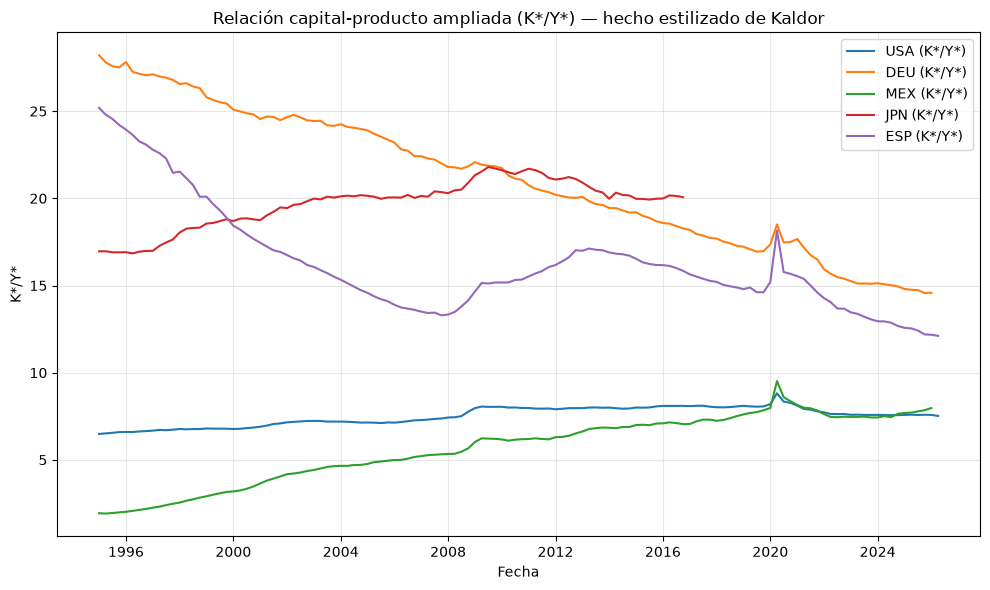

In [46]:
paises_fig = ['USA', 'DEU', 'MEX', 'JPN', 'ESP']
fig, ax = plt.subplots(figsize=(10, 6))
for pais in paises_fig:
    serie = panel.loc[pais][['K_Y_estandar', 'Kstar_Ystar']].dropna()
    ax.plot(serie.index, serie['Kstar_Ystar'], label=f'{pais} (K*/Y*)')

ax.set_title('Relación capital-producto ampliada (K*/Y*) — hecho estilizado de Kaldor')
ax.set_xlabel('Fecha')
ax.set_ylabel('K*/Y*')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('/Users/isa/puremacro/parte4_kaldor.png', dpi=150)
plt.show()

In [47]:
from scipy import stats

paises_tendencia = ['USA', 'DEU', 'MEX', 'JPN', 'ESP', 'FRA', 'GBR', 'KOR']
resultados_tendencia = {}

for pais in paises_tendencia:
    serie = panel.loc[pais]['Kstar_Ystar'].dropna()
    if len(serie) < 20:
        continue
    t = np.arange(len(serie))
    log_serie = np.log(serie.values)
    pendiente, intercepto, r, p, se = stats.linregress(t, log_serie)
    pendiente_anual = pendiente * 4 * 100 
    resultados_tendencia[pais] = {
        'pendiente_pct_anual': pendiente_anual,
        'periodo_inicio': serie.index[0].year,
        'periodo_fin': serie.index[-1].year,
        'r2': r**2
    }

tabla_tendencia = pd.DataFrame(resultados_tendencia).T
print(tabla_tendencia)

     pendiente_pct_anual  periodo_inicio  periodo_fin        r2
USA             0.617568          1995.0       2026.0  0.623838
DEU            -2.090774          1995.0       2026.0  0.985314
MEX             4.253210          1995.0       2026.0  0.852435
JPN             0.907967          1995.0       2016.0  0.659446
ESP            -1.372171          1995.0       2026.0  0.536144
FRA            -2.109571          1995.0       2026.0  0.926487
GBR             0.957768          1995.0       2026.0  0.838680
KOR             0.405315          1995.0       2026.0  0.378228


In [48]:
paises_publicada = set(tabla_final[tabla_final['tipo'] == 'publicada']['code'].unique())
paises_transformada = set(tabla_final[tabla_final['tipo'] == 'transformada']['code'].unique())

print("Países solo en publicada (no en transformada):", paises_publicada - paises_transformada)
print("Países en ambas:", len(paises_publicada & paises_transformada))

paises_comunes = paises_publicada & paises_transformada
tabla_final_balanceada = tabla_final[tabla_final['code'].isin(paises_comunes)]

resumen_balanceado = tabla_final_balanceada.groupby(['variable', 'filtro', 'tipo'])[['sigma', 'sigma_y', 'sigma_rel', 'corr_y']].mean()
print(resumen_balanceado)


Países solo en publicada (no en transformada): {'COL', 'SAU', 'BRA', 'CHE', 'CHN', 'ARG', 'IDN', 'AUS', 'RUS', 'IND'}
Países en ambas: 39
                                    sigma   sigma_y  sigma_rel    corr_y
variable filtro   tipo                                                  
C        hamilton publicada      4.487833  5.676786   0.761715  0.742212
         hp       publicada      2.370532  2.971016   0.740942  0.696669
C*       hamilton transformada   4.079501  5.692641   0.693855  0.808806
         hp       transformada   2.196658  3.128428   0.659039  0.772796
I        hamilton publicada     13.365983  5.676786   2.582931  0.733214
         hp       publicada      7.704237  2.971016   2.855466  0.686396
I*       hamilton transformada  12.021331  5.692641   2.290462  0.892725
         hp       transformada   6.806526  3.128428   2.467776  0.908907
Y        hamilton publicada      5.676786  5.676786   1.000000  1.000000
         hp       publicada      2.971016  2.971016   1.000